<a href="https://colab.research.google.com/github/knight19720208ui/TIP_Taller_BigData/blob/main/Taller_BigData3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import time
import pyspark.sql.functions as F
from pyspark.sql import Window
from pyspark.sql.types import *

# Iniciamos Spark con configuración optimizada para Colab
from pyspark.sql import SparkSession
spark = (SparkSession.builder
    .appName("TIP_Fraude_BigData")
    # ¡CLAVE! Reduce el overhead en la nube
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Motor de Big Data optimizado encendido.")

Motor de Big Data optimizado encendido.


In [6]:
print("Generando 15,000,000 de transacciones financieras... Por favor espera.")
start_time = time.time()

# Tabla de Usuarios (500,000)
df_users = spark.range(500000).withColumnRenamed("id", "user_id") \
    .withColumn("ciudad", F.when(F.rand() < 0.3, "Bogotá")
                       .when(F.rand() < 0.6, "Medellín")
                       .otherwise("Cali"))

# Tabla de Transacciones (15,000,000) - La tabla GIGANTE
df_tx = spark.range(15000000).withColumnRenamed("id", "tx_id") \
    .withColumn("user_id", (F.rand(seed=42) * 500000).cast("int")) \
    .withColumn("monto", (F.rand(seed=43) * 2000 + 5).cast("double")) \
    .withColumn("hora_dia", (F.rand(seed=44) * 24).cast("int")) \
    .withColumn("es_fraude_real", F.when(F.rand(seed=45) < 0.001, 1).otherwise(0)) # 0.1% de fraude

print(f"Datos generados en {time.time() - start_time:.2f} segundos.")

Generando 15,000,000 de transacciones financieras... Por favor espera.
Datos generados en 2.48 segundos.


In [7]:
print("Ejecutando JOIN distribuido de 15M con 500K registros...")
print("¡Esto tardará un rato! Observen cómo Spark trabaja (barra de progreso o espera).")
start_time = time.time()

# Cruce masivo
df_completo = df_tx.join(df_users, on="user_id", how="left")

# Forzamos una acción para que Spark realmente procese el Join
print(f"Total de filas crudas: {df_completo.count():,}")
print(f"El JOIN tardó: {time.time() - start_time:.2f} segundos.") # Normalmente tarda entre 20 y 50 seg en Colab

Ejecutando JOIN distribuido de 15M con 500K registros...
¡Esto tardará un rato! Observen cómo Spark trabaja (barra de progreso o espera).
Total de filas crudas: 15,000,000
El JOIN tardó: 7.93 segundos.


In [8]:
print("Calculando promedios históricos por usuario (Window Function)...")
start_time = time.time()

# Definimos la ventana: Particionar por usuario, ordenar por monto descendente
ventana_usuario = Window.partitionBy("user_id").orderBy(F.col("monto").desc())

# Calculamos el ranking de la transacción más cara de cada usuario
df_analisis = df_completo.withColumn("rank_monto", F.rank().over(ventana_usuario))

# Filtramos solo las transacciones que fueron la más cara para cada usuario
df_top_transacciones = df_analisis.filter(F.col("rank_monto") == 1)

print(f"El análisis de ventanas tardó: {time.time() - start_time:.2f} segundos.")
df_top_transacciones.show(5)

Calculando promedios históricos por usuario (Window Function)...
El análisis de ventanas tardó: 0.17 segundos.
+-------+--------+------------------+--------+--------------+------+----------+
|user_id|   tx_id|             monto|hora_dia|es_fraude_real|ciudad|rank_monto|
+-------+--------+------------------+--------+--------------+------+----------+
|      5| 5926994|1933.4187641852466|      18|             0|Bogotá|         1|
|      6| 7680955|1765.1581426064263|      20|             0|  Cali|         1|
|      9| 1891039|1949.6579832881991|       8|             0|Bogotá|         1|
|     10|10834371|2001.6039884950144|      13|             0|Bogotá|         1|
|     12| 4911963|1924.7268424083002|       8|             0|  Cali|         1|
+-------+--------+------------------+--------+--------------+------+----------+
only showing top 5 rows


In [9]:
print("Aplicando CACHÉ a la tabla procesada...")
df_top_transacciones.cache() # ¡Magia!

print("Primera consulta (Tarda porque ejecuta todo el pipeline oculto)...")
start_time = time.time()
count1 = df_top_transacciones.count()
print(f"Registros: {count1:,} - Tiempo: {time.time() - start_time:.2f} seg.")

print("\nSegunda consulta (¡Instantánea porque ya está en CACHÉ!)...")
start_time = time.time()
df_top_transacciones.filter(F.col("es_fraude_real") == 1).count()
print(f"Tiempo de la segunda consulta: {time.time() - start_time:.2f} seg.") # Debería ser 0.1 seg

Aplicando CACHÉ a la tabla procesada...
Primera consulta (Tarda porque ejecuta todo el pipeline oculto)...
Registros: 500,000 - Tiempo: 36.17 seg.

Segunda consulta (¡Instantánea porque ya está en CACHÉ!)...
Tiempo de la segunda consulta: 0.74 seg.


Agrupando para visualización final...


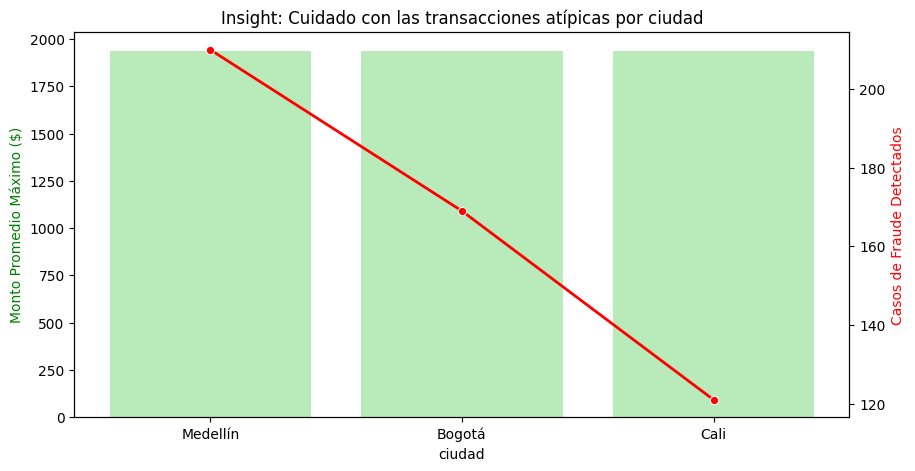

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Agrupando para visualización final...")
# ¿En qué ciudad se concentran las transacciones más altas (posible fraude)?
df_agg = df_top_transacciones.groupBy("ciudad") \
    .agg(
        F.sum("es_fraude_real").alias("casos_fraude"),
        F.avg("monto").alias("monto_promedio")
    ).toPandas()

# Gráfico
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(x='ciudad', y='monto_promedio', data=df_agg, ax=ax1, color='lightgreen', alpha=0.7)
ax1.set_ylabel('Monto Promedio Máximo ($)', color='green')

ax2 = ax1.twinx()
sns.lineplot(x='ciudad', y='casos_fraude', data=df_agg, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Casos de Fraude Detectados', color='red')

plt.title('Insight: Cuidado con las transacciones atípicas por ciudad')
plt.show()